# Import 

In [12]:
import pandas as pd 
import numpy as np
from scipy.stats import ks_2samp, anderson_ksamp


import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, PowerTransformer, QuantileTransformer


from trading_robot.data_collection.data_collector import DataCollector

# Function for notebook

In [2]:
def filter_correlated_pairs(correlation_matrix, threshold=0.7):
    correlated_pairs = []
    
    # Проходим по корреляционной матрице и выбираем валютные пары по порогу
    for i in range(len(correlation_matrix.columns)):
        for j in range(i + 1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) >= threshold:
                pair = (correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j])
                correlated_pairs.append(pair)
                
    return correlated_pairs

def check_distribution_similarity(data, symbols, p_value_threshold=0.05, verbose= False, return_list=False):
    similar_pairs = []
    
    # Проходим по всем валютным парам
    for i in range(len(symbols)):
        for j in range(i + 1, len(symbols)):
            symbol_1 = symbols[i]
            symbol_2 = symbols[j]
            
            # Тест Колмогорова-Смирнова
            ks_stat, ks_p_value = ks_2samp(data[symbol_1].dropna(), data[symbol_2].dropna())
            
            # Если p-значение выше порога, то распределения считаются схожими
            if ks_p_value > p_value_threshold:
                similar_pairs.append((symbol_1, symbol_2, ks_stat, ks_p_value))
    
    if verbose:
        # Вывод валютных пар с похожими распределениями
        print(f"Валютные пары с похожими распределениями (p-значение > {threshold}):")
        for pair in similar_pairs:
            print(f"Пара {pair[0]} и {pair[1]}: K-S Статистика = {pair[2]:.8f}, p-значение = {pair[3]:.8f}")

        # Пример дальнейшей работы с выбранными валютными парами
        selected_symbols = list(set([pair[0] for pair in similar_pairs] + [pair[1] for pair in similar_pairs]))
        print(f"Выбранные валютные пары для обучения модели: {selected_symbols}")
    
    if return_list:
        return selected_symbols
    
    return similar_pairs

def plot_distribution(data, selected_symbols, title="Распределение цен закрытия для каждой валютной пары"):
    """
    Функция для визуализации плотности распределений валютных пар.

    Параметры:
    data (pd.DataFrame): Датафрейм с данными цен закрытия валютных пар.
    selected_symbols (list): Список выбранных валютных пар для визуализации.
    title (str): Заголовок для графика (по умолчанию "Распределение цен закрытия для каждой валютной пары").

    Возвращает:
    None: Просто рисует графики плотности.
    """
    
    plt.figure(figsize=(10, 6))

    # Генерация графиков плотности для каждой выбранной валютной пары
    for symbol in selected_symbols:
        sns.kdeplot(data[symbol], label=symbol, fill=True)
    
    # Добавление заголовка и легенды
    plt.title(title)
    plt.legend()
    plt.show();

def normalize_and_check(data, scaler_class, correlated_symbols, threshold=0.005, verbose=True):
    """
    Функция для нормализации данных, проверки схожести распределений и визуализации.

    Параметры:
    - data (pd.DataFrame): Датафрейм с ценами закрытия валютных пар.
    - scaler_class: Класс скалера для нормализации данных (например, StandardScaler, MinMaxScaler).
    - correlated_symbols (list): Список коррелированных символов.
    - threshold (float): Порог для p-значения в тесте Колмогорова-Смирнова.
    - verbose (bool): Если True, выводит подробную информацию о схожести распределений.

    Возвращает:
    - distribution_selected_symbols (list): Список выбранных валютных пар с похожими распределениями.
    """
    
    # Создаем экземпляр скалера
    scaler = scaler_class()
    
    # Масштабируем данные
    normalized_data = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
    
    # Проверка схожести распределений
    distribution_selected_symbols = check_distribution_similarity(
        normalized_data, 
        correlated_symbols, 
        p_value_threshold=threshold, 
        verbose=verbose, 
        return_list=True
    )
    
    # Визуализация результатов
    plot_distribution(normalized_data, distribution_selected_symbols)
    
    return distribution_selected_symbols



# Data collection  

In [3]:
data_col = DataCollector()
all_symbols = data_col.get_all_symbols()
symbols = [ i  for i in  all_symbols if len(i) == 6 and "-" not in i]

In [4]:
len(symbols)

136

In [6]:
# symbols = ["EURUSD", "AUDCAD", "GBPUSD", "USDJPY", "USDCAD"]  # Пример списка валютных пар

close_prices = pd.DataFrame()

for symbol in symbols:
    try:
        data = data_col.get_historical_data(symbol=symbol)
        if data is not None:
            close_prices[symbol] = data['Close']
    except TypeError:
        print(f'{symbol} is not found')



2024-09-09 22:29:41 - Data retrieved successfully for symbol: AUDCAD, timeframe: 16408, count: 30000
2024-09-09 22:29:41 - Data retrieved successfully for symbol: AUDCHF, timeframe: 16408, count: 30000
2024-09-09 22:29:41 - Data retrieved successfully for symbol: AUDDKK, timeframe: 16408, count: 30000
2024-09-09 22:29:41 - Data retrieved successfully for symbol: AUDHKD, timeframe: 16408, count: 30000
2024-09-09 22:29:41 - Data retrieved successfully for symbol: AUDHUF, timeframe: 16408, count: 30000
2024-09-09 22:29:41 - Data retrieved successfully for symbol: AUDJPY, timeframe: 16408, count: 30000
2024-09-09 22:29:41 - Data retrieved successfully for symbol: AUDNOK, timeframe: 16408, count: 30000
2024-09-09 22:29:42 - Data retrieved successfully for symbol: AUDNZD, timeframe: 16408, count: 30000
2024-09-09 22:29:42 - Data retrieved successfully for symbol: AUDPLN, timeframe: 16408, count: 30000
2024-09-09 22:29:42 - Data retrieved successfully for symbol: AUDSEK, timeframe: 16408, cou

# None procesion 

In [7]:
close_prices.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 8125 entries, 1993-04-27 to 2024-09-09
Columns: 135 entries, AUDCAD to ZARJPY
dtypes: float64(135)
memory usage: 8.4 MB


In [8]:
symbols_nan = close_prices.isna().sum()
select_columns = symbols_nan[symbols_nan <= len(close_prices) / 2].index.to_list()

select_close_prices = close_prices[select_columns]

select_symbols_close_prices = select_close_prices.dropna(axis=0)

# Correlation

In [24]:
# Рассчет корреляционной матрицы
correlation_matrix = select_symbols_close_prices.corr()


# Задание порога корреляции (например, корреляция больше 0.7 или меньше -0.7)
threshold = 0.7
correlated_pairs = filter_correlated_pairs(correlation_matrix, threshold)

# Вывод всех валютных пар, которые коррелируют по порогу
print(f"Валютные пары с корреляцией выше {threshold}:")
for pair in correlated_pairs:
    print(f"Пара {pair[0]} и {pair[1]}: Корреляция = {pair[2]:.2f}")

# Пример фильтрации исходных данных по коррелирующим валютным парам
correlated_selected_symbols = list(set([pair[0] for pair in correlated_pairs] + [pair[1] for pair in correlated_pairs]))
print(f"Выбранные по корреляции валютные пары для обучения модели: {correlated_selected_symbols}")


Валютные пары с корреляцией выше 0.7:
Пара AUDCAD и AUDUSD: Корреляция = 0.75
Пара AUDCAD и EURAUD: Корреляция = -0.79
Пара AUDCAD и NZDCHF: Корреляция = 0.72
Пара AUDCAD и NZDSGD: Корреляция = 0.80
Пара AUDCAD и NZDUSD: Корреляция = 0.84
Пара AUDCHF и AUDNZD: Корреляция = 0.82
Пара AUDCHF и AUDUSD: Корреляция = 0.93
Пара AUDCHF и CADCHF: Корреляция = 0.95
Пара AUDCHF и CHFJPY: Корреляция = -0.82
Пара AUDCHF и EURCHF: Корреляция = 0.79
Пара AUDCHF и EURRUR: Корреляция = -0.89
Пара AUDCHF и EURUSD: Корреляция = 0.80
Пара AUDCHF и GBPCHF: Корреляция = 0.83
Пара AUDCHF и GBPUSD: Корреляция = 0.79
Пара AUDCHF и NZDCHF: Корреляция = 0.90
Пара AUDCHF и NZDSGD: Корреляция = 0.75
Пара AUDCHF и NZDUSD: Корреляция = 0.72
Пара AUDCHF и SGDJPY: Корреляция = -0.78
Пара AUDCHF и USDCAD: Корреляция = -0.93
Пара AUDCHF и USDDKK: Корреляция = -0.80
Пара AUDCHF и USDJPY: Корреляция = -0.84
Пара AUDCHF и USDMXN: Корреляция = -0.81
Пара AUDCHF и USDNOK: Корреляция = -0.94
Пара AUDCHF и USDSEK: Корреляция 

In [25]:
len(correlated_selected_symbols)

35

2024-09-09 22:31:36 - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2024-09-09 22:31:36 - Loaded backend module://matplotlib_inline.backend_inline version unknown.
2024-09-09 22:31:36 - findfont: Matching sans\-serif:style=normal:variant=normal:weight=normal:stretch=normal:size=10.0.
2024-09-09 22:31:36 - findfont: score(FontEntry(fname='/home/alex/miniconda3/envs/tr_env/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/STIXSizOneSymReg.ttf', name='STIXSizeOneSym', style='normal', variant='normal', weight=400, stretch='normal', size='scalable')) = 10.05
2024-09-09 22:31:36 - findfont: score(FontEntry(fname='/home/alex/miniconda3/envs/tr_env/lib/python3.10/site-packages/matplotlib/mpl-data/fonts/ttf/DejaVuSerif-Italic.ttf', name='DejaVu Serif', style='italic', variant='normal', weight=400, stretch='normal', size='scalable')) = 11.05
2024-09-09 22:31:36 - findfont: score(FontEntry(fname='/home/alex/miniconda3/envs/tr_env/lib/python3.10/site-packages/m

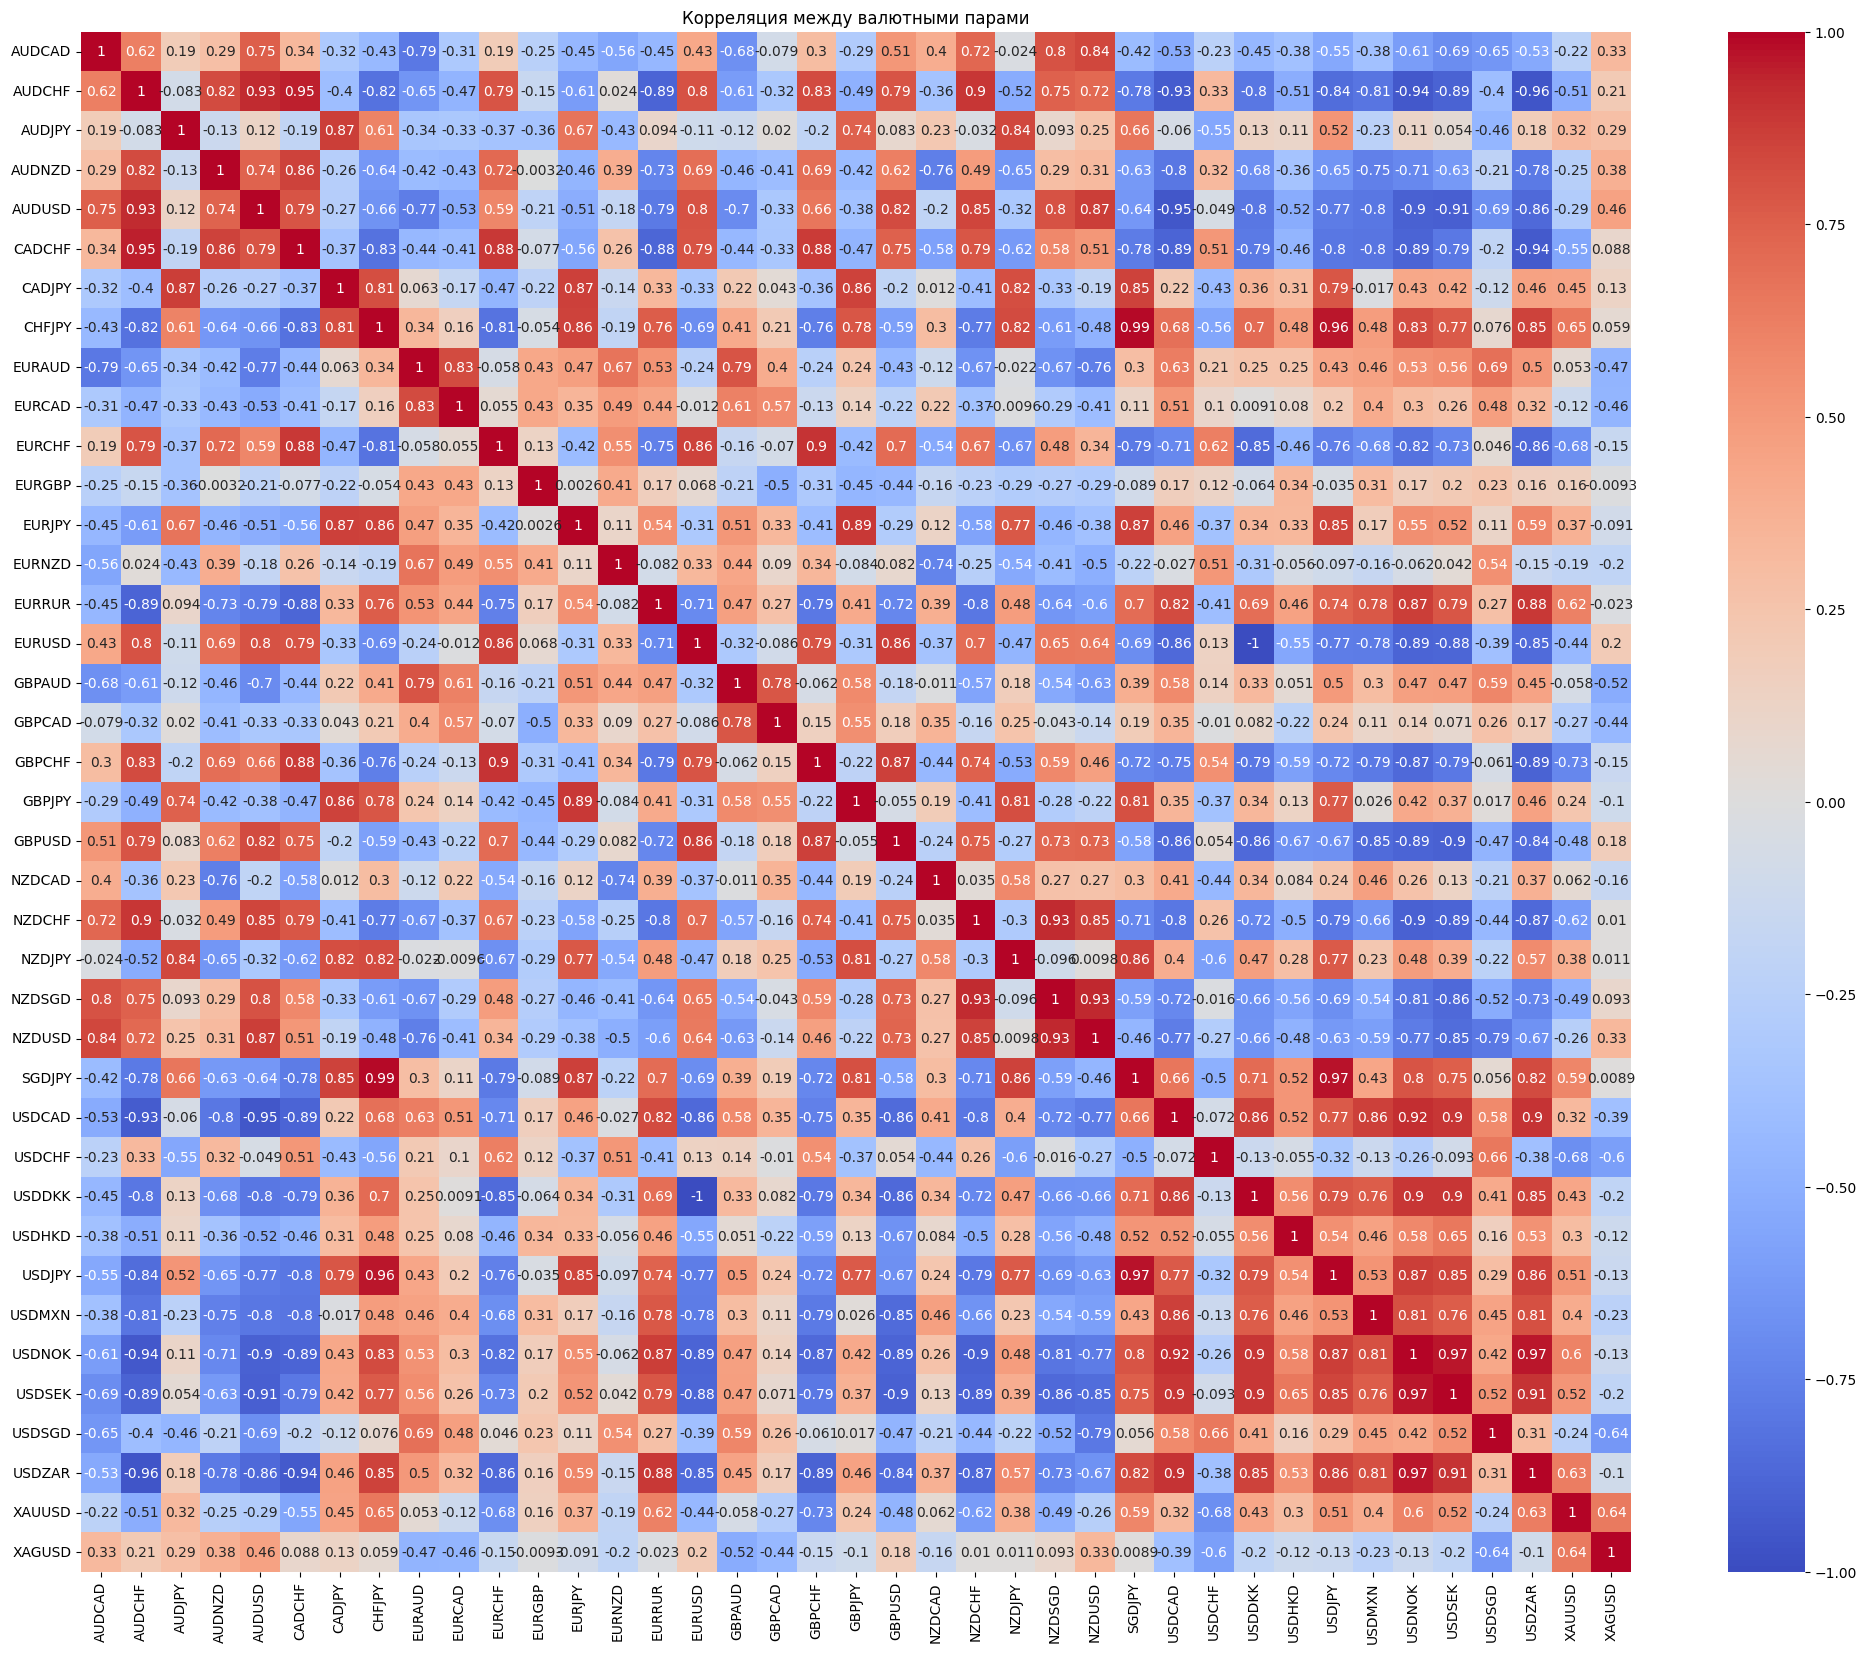

In [11]:

# Визуализация корреляционной матрицы
plt.figure(figsize=(25, 20))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Корреляция между валютными парами")
plt.show();

# Distribution

In [13]:
threshold = 0.001


Валютные пары с похожими распределениями (p-значение > 0.001):
Пара AUDCHF и GBPJPY: K-S Статистика = 0.04539047, p-значение = 0.00133851
Пара CADJPY и GBPJPY: K-S Статистика = 0.03918805, p-значение = 0.00861183
Пара CADJPY и XAGUSD: K-S Статистика = 0.04087962, p-значение = 0.00532569
Пара CHFJPY и SGDJPY: K-S Статистика = 0.04398083, p-значение = 0.00209310
Пара EURCAD и NZDJPY: K-S Статистика = 0.04144347, p-значение = 0.00451690
Пара NZDCAD и NZDSGD: K-S Статистика = 0.04313504, p-значение = 0.00271862
Пара NZDCHF и NZDSGD: K-S Статистика = 0.03918805, p-значение = 0.00861183
Выбранные валютные пары для обучения модели: ['SGDJPY', 'NZDCHF', 'GBPJPY', 'AUDCHF', 'NZDCAD', 'NZDSGD', 'EURCAD', 'XAGUSD', 'CADJPY', 'CHFJPY', 'NZDJPY']


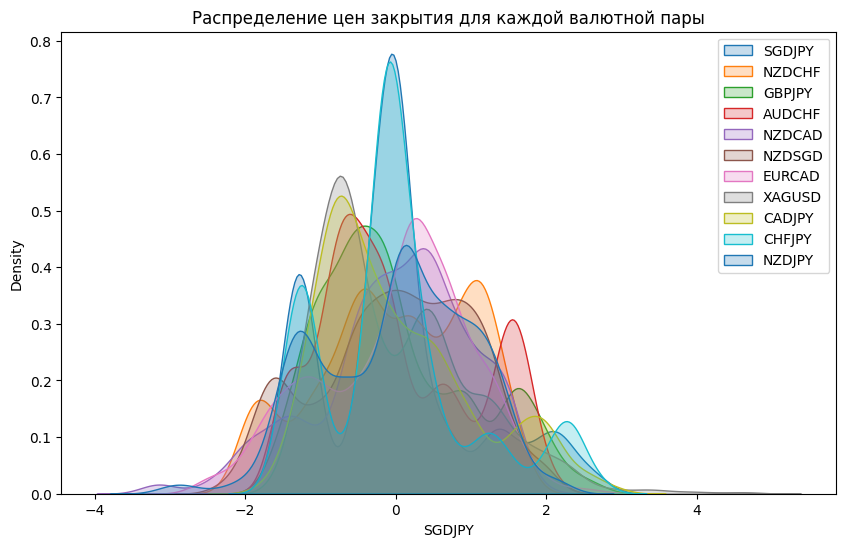

In [16]:
# Используем StandardScaler
distribution_selected_symbols_standard = normalize_and_check(
    select_symbols_close_prices, 
    StandardScaler,
    select_symbols_close_prices.columns,
    # correlated_selected_symbols, 
    threshold=threshold)

Валютные пары с похожими распределениями (p-значение > 0.001):
Пара CADJPY и GBPJPY: K-S Статистика = 0.04510854, p-значение = 0.00146537
Пара CADJPY и XAGUSD: K-S Статистика = 0.04228926, p-значение = 0.00351316
Пара NZDCHF и NZDSGD: K-S Статистика = 0.03354948, p-значение = 0.03690408
Выбранные валютные пары для обучения модели: ['NZDSGD', 'GBPJPY', 'XAGUSD', 'CADJPY', 'NZDCHF']


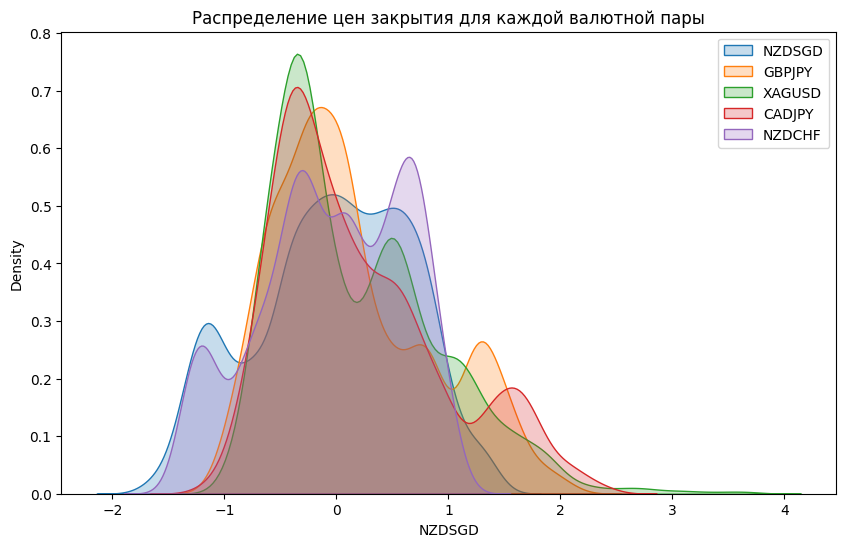

In [18]:

# Используем RobustScaler
distribution_selected_symbols_robust = normalize_and_check(
    select_symbols_close_prices, 
    RobustScaler,
    select_symbols_close_prices.columns,
    # correlated_selected_symbols,
    threshold=threshold)


Валютные пары с похожими распределениями (p-значение > 0.001):
Пара CHFJPY и SGDJPY: K-S Статистика = 0.03354948, p-значение = 0.03690408
Выбранные валютные пары для обучения модели: ['SGDJPY', 'CHFJPY']


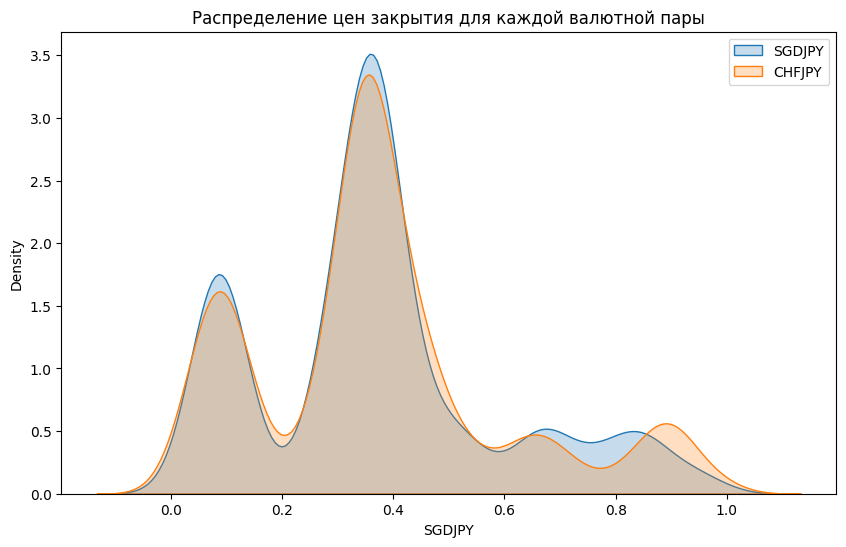

In [17]:
# Используем MinMaxScaler
distribution_selected_symbols_minmax = normalize_and_check(
    select_symbols_close_prices, 
    MinMaxScaler, 
    select_symbols_close_prices.columns,
    # correlated_selected_symbols, 
    threshold=threshold)


# Conclusion:

### The data is not similar in distribution and therefore some simple models like linear regression cannot be considered, but due to the correlation it is still possible to experiment with models that are insensitive to distribution SVM, Random Forest, AdaBoost and Neural Networks

In [28]:
correlated_selected_symbols

['SGDJPY',
 'USDCAD',
 'USDDKK',
 'NZDUSD',
 'EURNZD',
 'NZDJPY',
 'USDSGD',
 'EURCHF',
 'EURRUR',
 'USDJPY',
 'USDZAR',
 'USDNOK',
 'NZDSGD',
 'EURCAD',
 'EURUSD',
 'USDSEK',
 'GBPAUD',
 'EURJPY',
 'XAUUSD',
 'AUDJPY',
 'AUDNZD',
 'NZDCAD',
 'GBPUSD',
 'GBPCAD',
 'AUDCAD',
 'EURAUD',
 'CADCHF',
 'AUDCHF',
 'GBPCHF',
 'CHFJPY',
 'GBPJPY',
 'USDMXN',
 'CADJPY',
 'NZDCHF',
 'AUDUSD']

## Data collection and processing

In [30]:
from trading_robot.future_inzenering.basic_future_inz import BasicFuture
from trading_robot.future_inzenering.talib_indicators import TLIndicators
from trading_robot.future_selection.basic_feature_selector import BasicFeatureSelector


In [42]:
symbols = ['SGDJPY', 'USDCAD', 'USDDKK',]
lag_features = 25 


bf = BasicFuture()
bfs = BasicFeatureSelector()

all_data = pd.DataFrame()

for index, symbol in enumerate(symbols):
    try:
        # load_data
        data = data_col.get_historical_data(symbol=symbol)
        if data is not None:
            # inzener features
            for column in ["Open", "High", "Low", "Volume"]:
                data = bf.create_lag_features(data, column=column, end=1)

            data = bf.create_lag_features(data, column="Close", end=lag_features)
            data = bf.double_exponential_smoothing(data)
            data = bf.exponential_smoothing(data)
            data = bf.triple_exponential_smoothing(data)
            data = bf.confidence_interval(data, column="FLClose")
            
            tl = TLIndicators(data=data)
            data = tl.all_talib_indicators()

            data["symbol"] = symbol

        else:
            raise TypeError(f"{symbol} is None")
        
        all_data = pd.concat([all_data, data] )

    except TypeError:
        print(f'{symbol} is not found')




2024-09-09 23:27:28 - Data retrieved successfully for symbol: SGDJPY, timeframe: 16408, count: 30000
2024-09-09 23:27:28 - Creating lag features for column 'Open' with lags from 1 to 1.
2024-09-09 23:27:28 - Lag features created with 1 lags.
2024-09-09 23:27:28 - Creating lag features for column 'High' with lags from 1 to 1.
2024-09-09 23:27:28 - Lag features created with 1 lags.
2024-09-09 23:27:29 - Creating lag features for column 'Low' with lags from 1 to 1.
2024-09-09 23:27:29 - Lag features created with 1 lags.
2024-09-09 23:27:29 - Creating lag features for column 'Volume' with lags from 1 to 1.
2024-09-09 23:27:29 - Lag features created with 1 lags.
2024-09-09 23:27:29 - Creating lag features for column 'Close' with lags from 1 to 25.
2024-09-09 23:27:29 - Lag features created with 25 lags.
2024-09-09 23:27:29 - Applying double exponential smoothing with alpha=0.9 and beta=0.1 on column 'FLClose'.
2024-09-09 23:27:29 - Double exponential smoothing applied successfully.
2024-09-

In [47]:
all_data.sort_index()

,Open,Close,High,Low,Volume,FLOpen,FLHigh,FLLow,FLVolume,FLClose,...,median23,mode23,std23,median115,mode115,std115,median220,mode220,std220,symbol
Date,,,,,,,,,,,,,,,,,,,,,
1993-07-09,1.28010,1.27850,1.28250,1.27630,1081,1.28420,1.28630,1.27900,1041.0,1.28000,...,1.28000,1.28000,0.000000,1.28000,1.28000,0.000000,1.280000,1.28000,0.000000,USDCAD
1993-07-12,1.27800,1.27830,1.28050,1.27550,971,1.28010,1.28250,1.27630,1081.0,1.27850,...,1.27925,1.27850,0.000530,1.27925,1.27850,0.000530,1.279250,1.27850,0.000530,USDCAD
1993-07-13,1.27760,1.28130,1.28130,1.27570,751,1.27800,1.28050,1.27550,971.0,1.27830,...,1.27850,1.27830,0.000750,1.27850,1.27830,0.000750,1.278500,1.27830,0.000750,USDCAD
1993-07-14,1.28100,1.28300,1.28500,1.27850,1101,1.27760,1.28130,1.27570,751.0,1.28130,...,1.27925,1.27830,0.000612,1.27925,1.27830,0.000612,1.279250,1.27830,0.000612,USDCAD
1993-07-15,1.28220,1.28060,1.28370,1.28030,521,1.28100,1.28500,1.27850,1101.0,1.28300,...,1.28000,1.27830,0.000627,1.28000,1.27830,0.000627,1.280000,1.27830,0.000627,USDCAD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-09-09,1.35660,1.35570,1.35768,1.35463,37733,1.35005,1.35823,1.34653,49264.0,1.35714,...,1.35928,1.34429,0.005440,1.36785,1.37572,0.006406,1.361275,1.34901,0.004888,USDCAD
2024-09-09,6.73046,6.76191,6.76191,6.72377,46353,6.71516,6.74207,6.68768,72683.0,6.73038,...,6.73292,6.66455,0.040936,6.88561,6.66455,0.011777,6.873110,6.66455,0.015791,USDDKK
2024-09-10,109.64100,109.53100,109.64100,109.42300,158,109.16100,110.00200,108.84600,88298.0,109.63300,...,111.17000,109.21800,1.294437,114.72700,114.51300,1.567942,111.839000,109.54300,2.227670,SGDJPY


In [ ]:
target = "Close"

feture = bfs.remove_features_low_variance(data)
feture = bfs.filter_features_by_spearman_corr(data[feture], target=target)
feture = bfs.select_features_by_mutual_info(data[feture], target=target)

selected_data = data[feture]
columns = [col for col in selected_data.columns if "lag" not in col and "FL" not in col and "Close" not in col]
lag_col = [col for col in selected_data.columns if "lag" in col.lower() or "FL" in col]

feture = bfs.filter_correlated_features(data[columns])
feture = feture + lag_col + [target]

